# Modelo Baseline
Se implementará un pipeline inicial simple que incluirá una pila de 1D-CNN, seguida capas densas con activación Sigmoid para la clasificación binaria.

In [48]:
import numpy as np
from sklearn.model_selection import train_test_split, GroupKFold, KFold
import torch

In [49]:
X_correct_original = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

X_original = np.vstack((X_correct_original, X_incorrect_original))
y_original = np.array([1]*X_correct_original.shape[0] + [0]*X_incorrect_original.shape[0])  

# Convertir a tensores de PyTorch
X_tensor_original = torch.tensor(X_original, dtype=torch.float32)
y_tensor_original = torch.tensor(y_original, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

# Obtener el número de muestras (N)
n_samples = X_tensor_original.shape[0]

# Crea un array con los índices de los grupos (videos originales)
original_index = np.arange(n_samples)

In [50]:
import torch
import torch.nn as nn

input_channels = X_tensor_original.shape[2]  # Número de características por frame (coordenadas x,y de 33 puntos)
seq_len = X_tensor_original.shape[1]         # Número de frames por secuencia (video)

class Baseline_CNN1D(nn.Module):
    def __init__(self, num_classes, input_channels=66, seq_len=50):
        super().__init__()

        # Convolución Depthwise: groups = input_channels
        # Cada coordenada se procesa de forma independiente

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=input_channels, kernel_size=3, padding=1, groups=input_channels),
            nn.BatchNorm1d(input_channels),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Conv1d(in_channels=input_channels, out_channels=input_channels, kernel_size=3, padding=1, groups=input_channels),
            nn.BatchNorm1d(input_channels),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2)

        )

        # Cálculo de las dimensiones para el aplanado
        flatten_dim = input_channels * (seq_len // 2)


        # Capas Densas (FFN) - Se combina la información de todas las coordenadas
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )


    def forward(self, x):
        # x original: (batch_size, seq_len, input_channels) -> (N, 160, 66)

        x = x.permute(0, 2, 1)  # (N, input_channels, seq_len)

        # Extracción de características (cada canal por separado)
        x = self.features(x)

        # Clasificación (combinando la información de todos los canales)
        x = self.classifier(x)

        return x

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
import numpy as np
import copy 

# =============================================================================
# 1. FUNCIÓN DE ENTRENAMIENTO (UNA ÉPOCA)
# =============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta el paso de entrenamiento para una sola época."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        
    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    return avg_loss, avg_acc

# =============================================================================
# 2. FUNCIÓN DE VALIDACIÓN (UNA ÉPOCA)
# =============================================================================
def validate_one_epoch(model, loader, criterion, device):
    """Ejecuta la evaluación sin calcular gradientes."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Listas para guardar predicciones (útil para el paso final del fold)
    preds_list = []
    labels_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            # Guardamos predicciones por si es la última pasada
            preds_list.extend(predicted.cpu().numpy())
            labels_list.extend(y_batch.cpu().numpy())
            
    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    
    return avg_loss, avg_acc, preds_list, labels_list

# =============================================================================
# 3. GESTOR DE UN SOLO PLIEGUE (FOLD MANAGER)
# =============================================================================
def train_single_fold(model, train_loader, val_loader, epochs, lr, patience, device):
    """Entrena un modelo desde cero para un fold específico con Early Stopping."""
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    
    # Variables de Early Stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    
    for epoch in range(epochs):
        # 1. Entrenar
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # 2. Validar
        val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)
        
        # 3. Guardar Historia
        history['loss'].append(train_loss)
        history['acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # 4. Lógica Early Stopping
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_weights = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"    ⏹️ Early stopping en época {epoch+1}")
                    break
    
    # 5. Restaurar el mejor modelo y hacer inferencia final
    if best_weights:
        model.load_state_dict(best_weights)
    
    # Hacemos una última pasada de validación con el MEJOR modelo para sacar las predicciones
    final_val_loss, final_val_acc, final_preds, final_labels = validate_one_epoch(model, val_loader, criterion, device)
    
    return final_val_acc, history, final_preds, final_labels

# =============================================================================
# 4. FUNCIÓN PRINCIPAL (ORQUESTADOR K-FOLD)
# =============================================================================
def run_kfold_experiment_pytorch(model_class, model_params, X_full, y_full, groups, 
                                       epochs, batch_size, lr=0.001, n_splits=5, patience=None, device='cpu'):
    
    # 1. Asegurar tipos numpy para que sklearn funcione
    if isinstance(X_full, torch.Tensor): X_full = X_full.cpu().numpy()
    if isinstance(y_full, torch.Tensor): y_full = y_full.cpu().numpy()

    # 2. Configurar GroupKFold
    # IMPORTANTE: GroupKFold no acepta shuffle=True ni random_state. 
    # La aleatoriedad depende de cómo estén ordenados los grupos en tu array 'groups'.
    gkf = GroupKFold(n_splits=n_splits)
    
    # Acumuladores Globales
    fold_accuracies = []
    fold_histories = []
    
    # Listas TEMPORALES para guardar resultados desordenados
    global_y_true_unsorted = []
    global_y_pred_unsorted = []
    global_indices = [] # <--- NECESARIO PARA REORDENAR LUEGO
    
    print(f"🚀 Iniciando GroupKFold Modular ({n_splits} splits) en {device}...")
    print(f"   Protección contra Data Leakage activa (Grupos únicos detectados: {len(np.unique(groups))})")
    print("===" * 20)

    # 3. Bucle K-Fold pasando 'groups'
    for fold_idx, (train_index, val_index) in enumerate(gkf.split(X_full, y_full, groups=groups)):
        print(f"\n🔄 Pliegue {fold_idx + 1}/{n_splits}")
        
        # A. Preparar Tensores y Loaders
        X_train_t = torch.tensor(X_full[train_index], dtype=torch.float32)
        y_train_t = torch.tensor(y_full[train_index], dtype=torch.long)
        X_val_t = torch.tensor(X_full[val_index], dtype=torch.float32)
        y_val_t = torch.tensor(y_full[val_index], dtype=torch.long)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
        
        # B. Inicializar Modelo (Nuevo para cada fold)
        model = model_class(**model_params).to(device)
        
        # C. Delegar el trabajo a la función 'train_single_fold'
        val_acc, history, fold_preds, fold_labels = train_single_fold(
            model, train_loader, val_loader, epochs, lr, patience, device
        )
        
        # D. Recolectar resultados
        print(f"    ✅ Fin Fold {fold_idx+1}. Mejor Acc Val: {val_acc:.4f}")
        
        fold_accuracies.append(val_acc)
        fold_histories.append(history)
        
        # Guardamos datos crudos Y LOS ÍNDICES de este fold
        global_y_true_unsorted.extend(fold_labels)
        global_y_pred_unsorted.extend(fold_preds)
        global_indices.extend(val_index) # <--- CLAVE PARA EL ORDEN

    # ==========================================================================
    # 4. REORDENAMIENTO FINAL (CRÍTICO)
    # ==========================================================================
    # GroupKFold procesa los bloques en desorden. Si no hacemos esto, 
    # y_pred[0] NO corresponderá a X_full[0].
    
    global_indices_np = np.array(global_indices)
    sorted_order = np.argsort(global_indices_np) # Obtenemos los índices que ordenarían el array
    
    # Reordenamos las predicciones y etiquetas usando ese orden
    final_y_true = np.array(global_y_true_unsorted)[sorted_order]
    final_y_pred = np.array(global_y_pred_unsorted)[sorted_order]

    # E. Resultados Finales
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    
    print("===" * 20)
    print(f"📊 Resultados GroupKFold:")
    print(f"| Accuracy Medio: {mean_acc:.4f} (+/- {std_acc:.4f})")
    
    return mean_acc, std_acc, fold_histories, final_y_true, final_y_pred

## EXP-CNN-01

In [52]:
# 1. Definir parámetros (ajusta seq_len a tus datos, ej. 50, 100, etc.)
params_baseline = {
    'num_classes': 2,
    'input_channels': input_channels, 
    'seq_len': seq_len
}

# 2. Entrenar usando tu función unificada
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=Baseline_CNN1D,  # <--- Pasamos la nueva clase
    model_params=params_baseline,
    X_full=X_tensor_original,
    y_full=y_tensor_original,
    groups=original_index,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,
    device='cpu'
)

🚀 Iniciando GroupKFold Modular (5 splits) en cpu...
   Protección contra Data Leakage activa (Grupos únicos detectados: 100)

🔄 Pliegue 1/5
    ⏹️ Early stopping en época 49
    ✅ Fin Fold 1. Mejor Acc Val: 0.8000

🔄 Pliegue 2/5
    ⏹️ Early stopping en época 53
    ✅ Fin Fold 2. Mejor Acc Val: 0.7000

🔄 Pliegue 3/5
    ⏹️ Early stopping en época 37
    ✅ Fin Fold 3. Mejor Acc Val: 0.5000

🔄 Pliegue 4/5
    ⏹️ Early stopping en época 50
    ✅ Fin Fold 4. Mejor Acc Val: 0.6500

🔄 Pliegue 5/5
    ⏹️ Early stopping en época 61
    ✅ Fin Fold 5. Mejor Acc Val: 0.8000
📊 Resultados GroupKFold:
| Accuracy Medio: 0.6900 (+/- 0.1114)


### Evaluación con Bootstrapping

In [53]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import numpy as np

def calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """
    Calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.
    """
    stats = []
    
    # 1. Bucle de simulaciones (1000 veces)
    for i in range(n_iterations):
        # Generamos índices aleatorios con reemplazo
        # (Simula meter la mano en la bolsa y sacar bolas repetidas)
        indices = resample(range(len(y_pred)), replace=True)
        
        # Creamos el "dataset virtual"
        sample_pred = y_pred[indices]
        sample_true = y_true[indices]
        
        # Calculamos el accuracy de esta simulación
        score = accuracy_score(sample_true, sample_pred)
        stats.append(score)
    
    # 2. Ordenamos los 1000 resultados de menor a mayor
    stats = np.sort(stats)
    
    # 3. Calculamos los límites (cortamos las colas)
    lower_percentile = ((1.0 - alpha) / 2.0) * 100
    upper_percentile = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    lower = np.percentile(stats, lower_percentile)
    upper = np.percentile(stats, upper_percentile)
    
    print(f"Accuracy Promedio (Bootstrap): {np.mean(stats):.4f}")
    print(f"Intervalo de Confianza {int(alpha*100)}%: [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper, stats

Accuracy Promedio (Bootstrap): 0.6917
Intervalo de Confianza 95%: [0.6000, 0.7800]


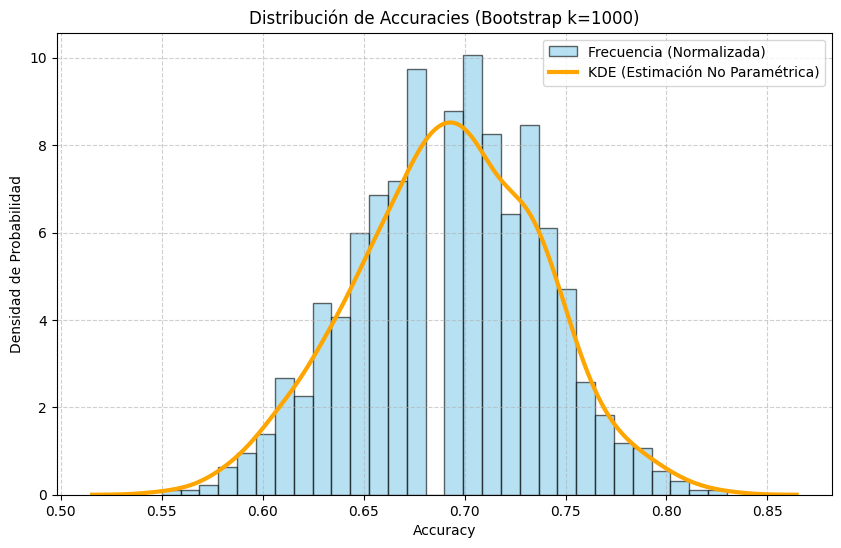

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficamos el histograma de accuracies bootstrap
n_iterations = 1000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=30, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)')

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [55]:
# Guardamos el array en disco para análisis posterior
np.save('../results/bootstrap_accuracies_exp_cnn_01.npy', stats)

## EXP-CNN-02

In [56]:
X_angles_correct = np.load('../Data/Processed/correct_push_ups_angles.npy')
X_angles_incorrect = np.load('../Data/Processed/wrong_push_ups_angles.npy')

X_angles = np.vstack((X_angles_correct, X_angles_incorrect))
y_angles = np.array([1]*X_angles_correct.shape[0] + [0]*X_angles_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_angles_tensor = torch.tensor(X_angles, dtype=torch.float32)
y_angles_tensor = torch.tensor(y_angles, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

input_channels = X_angles_tensor.shape[2]  # Número de características por frame (ángulos articulares)
seq_len = X_angles_tensor.shape[1]         # Número de frames por secuencia (video)


In [57]:
input_channels

10

In [58]:
# 1. Definir parámetros (ajusta seq_len a tus datos, ej. 50, 100, etc.)
params_baseline = {
    'num_classes': 2,
    'input_channels': input_channels, 
    'seq_len': seq_len
}

# 2. Entrenar usando tu función unificada
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=Baseline_CNN1D,  # <--- Pasamos la nueva clase
    model_params=params_baseline,
    X_full=X_angles_tensor,
    y_full=y_angles_tensor,
    groups=original_index,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,
    device='cpu'
)

🚀 Iniciando GroupKFold Modular (5 splits) en cpu...
   Protección contra Data Leakage activa (Grupos únicos detectados: 100)

🔄 Pliegue 1/5
    ⏹️ Early stopping en época 49
    ✅ Fin Fold 1. Mejor Acc Val: 0.7000

🔄 Pliegue 2/5
    ⏹️ Early stopping en época 73
    ✅ Fin Fold 2. Mejor Acc Val: 0.8500

🔄 Pliegue 3/5
    ⏹️ Early stopping en época 36
    ✅ Fin Fold 3. Mejor Acc Val: 0.5000

🔄 Pliegue 4/5
    ⏹️ Early stopping en época 41
    ✅ Fin Fold 4. Mejor Acc Val: 0.6000

🔄 Pliegue 5/5
    ⏹️ Early stopping en época 56
    ✅ Fin Fold 5. Mejor Acc Val: 0.8500
📊 Resultados GroupKFold:
| Accuracy Medio: 0.7000 (+/- 0.1378)


### Evaluación con Bootstrapping

Accuracy Promedio (Bootstrap): 0.7039
Intervalo de Confianza 95%: [0.6100, 0.7900]


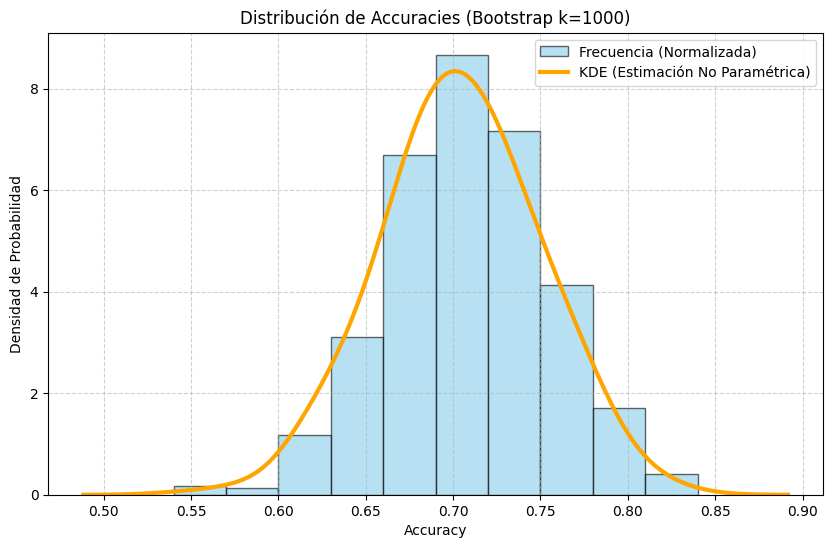

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficamos el histograma de accuracies bootstrap
n_iterations = 1000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=10, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)', bw_adjust=1.5)

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [60]:
# Guardamos el array en disco para análisis posterior
np.save('../results/bootstrap_accuracies_exp_cnn_02.npy', stats)

## EXP-CNN-03

In [61]:
X_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_landmarks.npy')
X_incorrect_mirrored = np.load('../Data/Processed/mirrored_wrong_push_ups_landmarks.npy')

X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*X_correct_mirrored.shape[0] + [0]*X_incorrect_mirrored.shape[0])  

# Convertir a tensores de PyTorch
X_tensor_mirrored = torch.tensor(X_mirrored, dtype=torch.float32)
y_tensor_mirrored = torch.tensor(y_mirrored, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

input_channels = X_tensor_mirrored.shape[2]  # Número de características por frame (coordenadas x,y de 33 puntos)
seq_len = X_tensor_mirrored.shape[1]         # Número de frames por secuencia (video)

# Obtener el número de muestras (N)
n_samples_mirrored = X_tensor_mirrored.shape[0]

# Crea un array con los índices de los grupos (videos originales)
mirrored_index = np.arange(n_samples_mirrored)

In [62]:
# Creamos un array con los índices de los grupos (videos originales)
groups = np.concatenate([original_index, mirrored_index])

# Concatenamos los datos originales y aumentados
X_tensor_concat = torch.cat((X_tensor_original, X_tensor_mirrored), dim=0)
y_tensor_concat = torch.cat((y_tensor_original, y_tensor_mirrored), dim=0)

groups

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99,  0,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
       87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [63]:
[fold for fold in GroupKFold(n_splits=5).split(X_tensor_concat, y_tensor_concat, groups=groups)]

[(array([  0,   1,   2,   4,   5,   6,   7,   9,  10,  11,  12,  14,  15,
          16,  17,  19,  20,  21,  22,  23,  25,  26,  27,  28,  30,  31,
          32,  33,  35,  36,  37,  38,  40,  41,  42,  43,  45,  46,  47,
          48,  50,  51,  52,  53,  55,  56,  57,  58,  60,  61,  62,  63,
          65,  66,  67,  68,  70,  71,  72,  73,  75,  76,  77,  78,  80,
          81,  82,  83,  85,  86,  87,  88,  90,  91,  92,  93,  95,  96,
          97,  98, 100, 101, 102, 104, 105, 106, 107, 109, 110, 111, 112,
         114, 115, 116, 117, 119, 120, 121, 122, 123, 125, 126, 127, 128,
         130, 131, 132, 133, 135, 136, 137, 138, 140, 141, 142, 143, 145,
         146, 147, 148, 150, 151, 152, 153, 155, 156, 157, 158, 160, 161,
         162, 163, 165, 166, 167, 168, 170, 171, 172, 173, 175, 176, 177,
         178, 180, 181, 182, 183, 185, 186, 187, 188, 190, 191, 192, 193,
         195, 196, 197, 198]),
  array([  3,   8,  13,  18,  24,  29,  34,  39,  44,  49,  54,  59,  64,
       

In [64]:
# 1. Definir parámetros (ajusta seq_len a tus datos, ej. 50, 100, etc.)
params_baseline = {
    'num_classes': 2,
    'input_channels': input_channels, 
    'seq_len': seq_len
}

# 2. Entrenar usando tu función unificada
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=Baseline_CNN1D,  # <--- Pasamos la nueva clase
    model_params=params_baseline,
    X_full=X_tensor_concat,
    y_full=y_tensor_concat,
    groups=groups,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,
    device='cpu'
)

🚀 Iniciando GroupKFold Modular (5 splits) en cpu...
   Protección contra Data Leakage activa (Grupos únicos detectados: 100)

🔄 Pliegue 1/5


    ⏹️ Early stopping en época 82
    ✅ Fin Fold 1. Mejor Acc Val: 0.9250

🔄 Pliegue 2/5
    ⏹️ Early stopping en época 79
    ✅ Fin Fold 2. Mejor Acc Val: 0.9250

🔄 Pliegue 3/5
    ⏹️ Early stopping en época 52
    ✅ Fin Fold 3. Mejor Acc Val: 0.9250

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Mejor Acc Val: 1.0000

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Mejor Acc Val: 1.0000
📊 Resultados GroupKFold:
| Accuracy Medio: 0.9550 (+/- 0.0367)


In [65]:
X_tensor_concat.shape
y_tensor_concat.shape

torch.Size([200])

### Evaluación con Bootstrapping

Accuracy Promedio (Bootstrap): 0.9551
Intervalo de Confianza 95%: [0.9250, 0.9800]


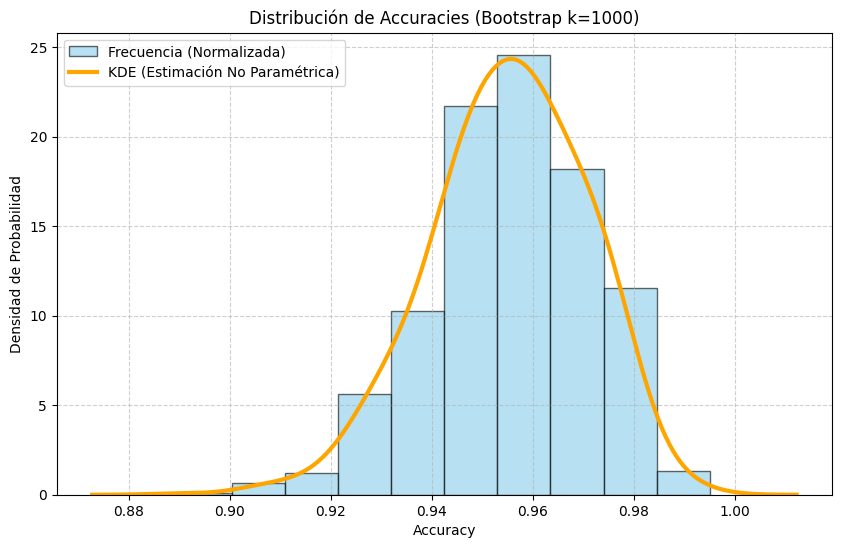

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficamos el histograma de accuracies bootstrap
n_iterations = 1000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=10, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)', bw_adjust=1.5)

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [67]:
# Guardamos el array en disco para análisis posterior
np.save('../results/bootstrap_accuracies_exp_cnn_03.npy', stats)

## EXP-CNN-04

In [68]:
X_angles_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_angles.npy')
X_angles_incorrect_mirrored =ANGLES = np.load('../Data/Processed/mirrored_wrong_push_ups_angles.npy')

X_angles_mirrored = np.vstack((X_angles_correct_mirrored, X_angles_incorrect_mirrored))
y_angles_mirrored = np.array([1]*X_angles_correct_mirrored.shape[0] + [0]*X_angles_incorrect_mirrored.shape[0])  

# Convertir a tensores de PyTorch
X_angles_tensor_mirrored = torch.tensor(X_angles_mirrored, dtype=torch.float32)
y_angles_tensor_mirrored = torch.tensor(y_angles_mirrored, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

input_angles_channels = X_angles_tensor_mirrored.shape[2]  # Número de características por frame (coordenadas x,y de 33 puntos)
seq_angles_len = X_angles_tensor_mirrored.shape[1]         # Número de frames por secuencia (video)

# Obtener el número de muestras (N)
n_samples_angles_mirrored = X_angles_tensor_mirrored.shape[0]

# Crea un array con los índices de los grupos (videos originales)
angles_mirrored_index = np.arange(n_samples_angles_mirrored)

In [69]:
# Creamos un array con los índices de los grupos (videos originales)
groups = np.concatenate([original_index, angles_mirrored_index])

# Concatenamos los datos originales y aumentados
X_tensor_concat = torch.cat((X_angles_tensor, X_angles_tensor_mirrored), dim=0)
y_tensor_concat = torch.cat((y_angles_tensor, y_angles_tensor_mirrored), dim=0)


In [70]:
# 1. Definir parámetros (ajusta seq_len a tus datos, ej. 50, 100, etc.)
params_baseline = {
    'num_classes': 2,
    'input_channels': input_angles_channels, 
    'seq_len': seq_angles_len
}

# 2. Entrenar usando tu función unificada
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=Baseline_CNN1D,  # <--- Pasamos la nueva clase
    model_params=params_baseline,
    X_full=X_tensor_concat,
    y_full=y_tensor_concat,
    groups=groups,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,
    device='cpu'
)

🚀 Iniciando GroupKFold Modular (5 splits) en cpu...
   Protección contra Data Leakage activa (Grupos únicos detectados: 100)

🔄 Pliegue 1/5
    ✅ Fin Fold 1. Mejor Acc Val: 0.9000

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Mejor Acc Val: 0.9750

🔄 Pliegue 3/5
    ⏹️ Early stopping en época 83
    ✅ Fin Fold 3. Mejor Acc Val: 0.8500

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Mejor Acc Val: 0.9500

🔄 Pliegue 5/5
    ⏹️ Early stopping en época 50
    ✅ Fin Fold 5. Mejor Acc Val: 0.8750
📊 Resultados GroupKFold:
| Accuracy Medio: 0.9100 (+/- 0.0464)


### Evaluación con Bootstrapping

Accuracy Promedio (Bootstrap): 0.9103
Intervalo de Confianza 95%: [0.8650, 0.9500]


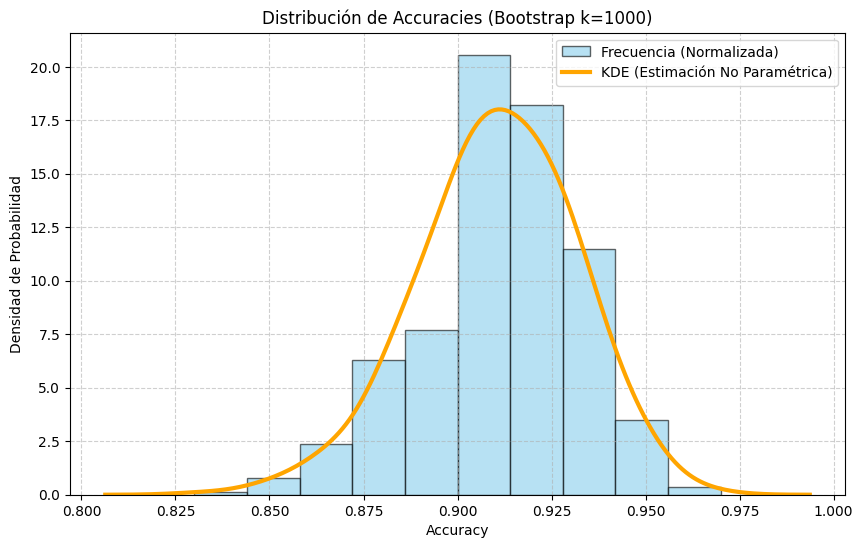

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficamos el histograma de accuracies bootstrap
n_iterations = 1000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=10, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)', bw_adjust=1.5)

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [72]:
# Guardamos el array en disco para análisis posterior
np.save('../results/bootstrap_accuracies_exp_cnn_04.npy', stats)